# Rabi oscillation results

Plots data saved by `rabi.py run <file_name>` from `D:\rabi\<file_name>\`:
- `<file_name>_rabi_mw_us.npy` / `_rabi_x.npy` / `_rabi_y.npy` -- the actual Rabi oscillation (SR830 X/Y vs. MW pulse length)
- `<file_name>_rabi_reflected_dbm.npy` -- interlock reflected-power checks (only every `interlock_check_interval` points, NaN elsewhere)
- `<file_name>_resonance_coarse.csv` / `_resonance_fine.csv` -- the pre-flight reflected-power sweep around the fixed drive frequency (if `reflected_power_scan=true`)
- `<file_name>_rabi_metadata.txt` -- the run's fixed parameters

## Load data

In [1]:
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = "D:/rabi"
FILE_NAMES = ["rabi1", "rabi2", "rabi3"]

runs = {}
for file_name in FILE_NAMES:
    run_path = f"{DATA_DIR}/{file_name}"

    mw_us = np.load(f"{run_path}/{file_name}_rabi_mw_us.npy")
    x_v = np.load(f"{run_path}/{file_name}_rabi_x.npy")
    y_v = np.load(f"{run_path}/{file_name}_rabi_y.npy")
    reflected_dbm = np.load(f"{run_path}/{file_name}_rabi_reflected_dbm.npy")

    with open(f"{run_path}/{file_name}_rabi_metadata.txt") as fh:
        metadata_text = fh.read()
    metadata = dict(
        (k, float(v)) for k, v in
        (line.split("=", 1) for line in metadata_text.strip().splitlines())
    )

    runs[file_name] = dict(
        run_path=run_path, mw_us=mw_us, x_v=x_v, y_v=y_v,
        reflected_dbm=reflected_dbm, metadata=metadata,
    )

    print(f"{file_name}: {len(mw_us)} points, tau_mw {mw_us.min():.3f}-{mw_us.max():.3f} us")
    print(metadata_text)


rabi1: 51 points, tau_mw 0.020-5.020 us
freq_hz=2843000000.0
drive_power_dbm=0.0
n_reps=50
laser_us=2.0
pre_us=1.0
post_us=1.0
time_constant_s=0.1
settle_periods=5.0
settle_time_constants=5.0
sensitivity_v=0.05
phase_deg=0.0

rabi2: 250 points, tau_mw 0.020-5.000 us
freq_hz=2843000000.0
drive_power_dbm=0.0
n_reps=250
laser_us=2.0
pre_us=1.0
post_us=1.0
time_constant_s=0.1
settle_periods=5.0
settle_time_constants=5.0
sensitivity_v=0.01
phase_deg=0.0

rabi3: 197 points, tau_mw 0.020-1.000 us
freq_hz=2843000000.0
drive_power_dbm=0.0
n_reps=250
laser_us=2.0
pre_us=1.0
post_us=1.0
time_constant_s=0.1
settle_periods=5.0
settle_time_constants=5.0
sensitivity_v=0.01
phase_deg=0.0



## Rabi oscillation: X, Y, R vs. tau_mw

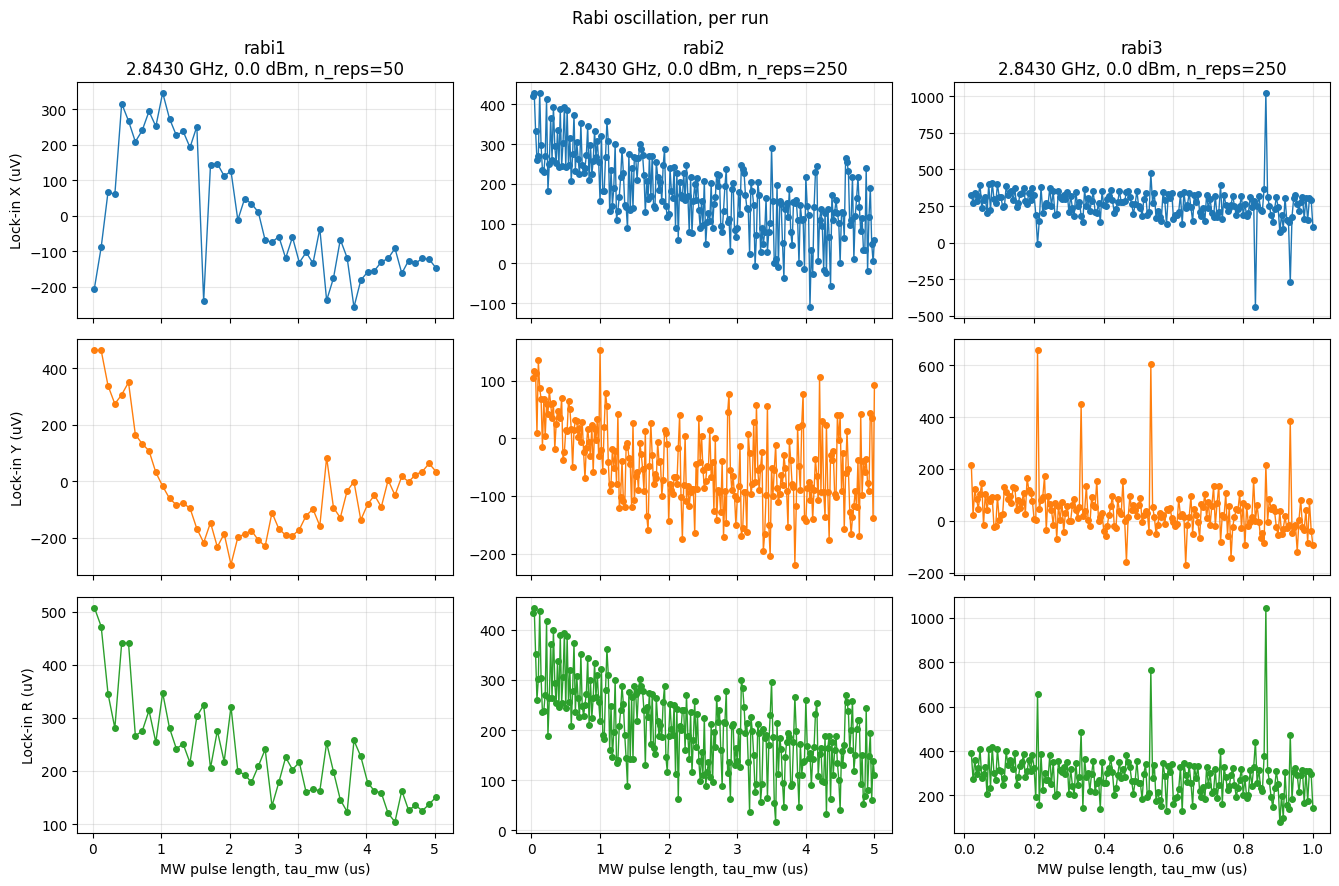

In [2]:
n_runs = len(runs)
fig, axes = plt.subplots(3, n_runs, figsize=(4.5 * n_runs, 9), sharex="col", squeeze=False)

for col, (file_name, d) in enumerate(runs.items()):
    r_v = np.sqrt(d["x_v"]**2 + d["y_v"]**2)
    axes[0, col].plot(d["mw_us"], d["x_v"] * 1e6, "o-", ms=4, lw=1, color="tab:blue")
    axes[1, col].plot(d["mw_us"], d["y_v"] * 1e6, "o-", ms=4, lw=1, color="tab:orange")
    axes[2, col].plot(d["mw_us"], r_v * 1e6, "o-", ms=4, lw=1, color="tab:green")

    freq_ghz = d["metadata"]["freq_hz"] / 1e9
    drive_dbm = d["metadata"]["drive_power_dbm"]
    n_reps = int(d["metadata"]["n_reps"])
    axes[0, col].set_title(f"{file_name}\n{freq_ghz:.4f} GHz, {drive_dbm:.1f} dBm, n_reps={n_reps}")

    axes[2, col].set_xlabel("MW pulse length, tau_mw (us)")
    for row in range(3):
        axes[row, col].grid(alpha=0.3)

axes[0, 0].set_ylabel("Lock-in X (uV)")
axes[1, 0].set_ylabel("Lock-in Y (uV)")
axes[2, 0].set_ylabel("Lock-in R (uV)")

fig.suptitle("Rabi oscillation, per run")
plt.tight_layout()
plt.show()


## Interlock: reflected power at checked points

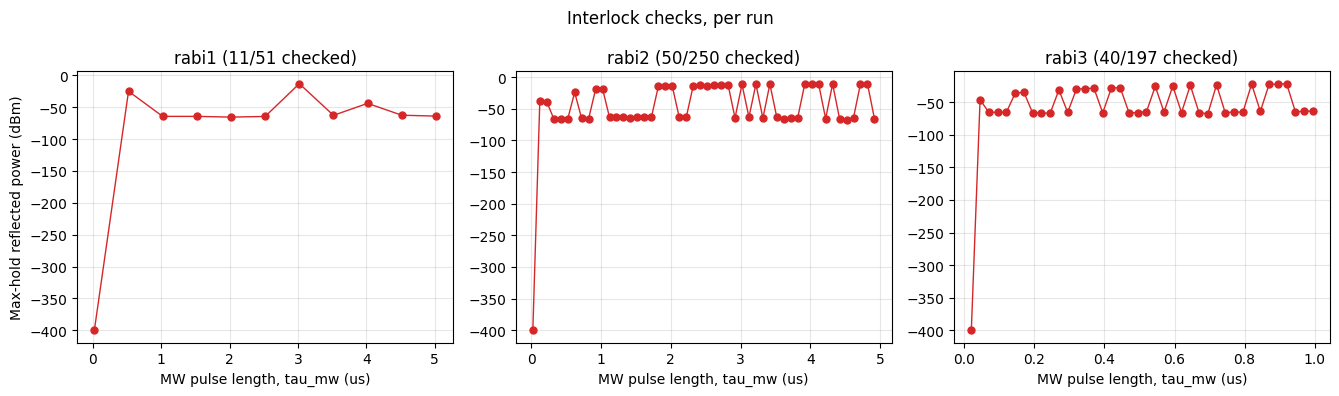

In [3]:
n_runs = len(runs)
fig, axes = plt.subplots(1, n_runs, figsize=(4.5 * n_runs, 4), squeeze=False)
axes = axes[0]

for col, (file_name, d) in enumerate(runs.items()):
    checked = ~np.isnan(d["reflected_dbm"])
    axes[col].plot(d["mw_us"][checked], d["reflected_dbm"][checked], "o-", ms=5, lw=1, color="tab:red")
    axes[col].set_xlabel("MW pulse length, tau_mw (us)")
    axes[col].set_title(f"{file_name} ({checked.sum()}/{len(d['mw_us'])} checked)")
    axes[col].grid(alpha=0.3)

axes[0].set_ylabel("Max-hold reflected power (dBm)")
fig.suptitle("Interlock checks, per run")
plt.tight_layout()
plt.show()


## Pre-flight reflected-power sweep (around the fixed drive frequency)

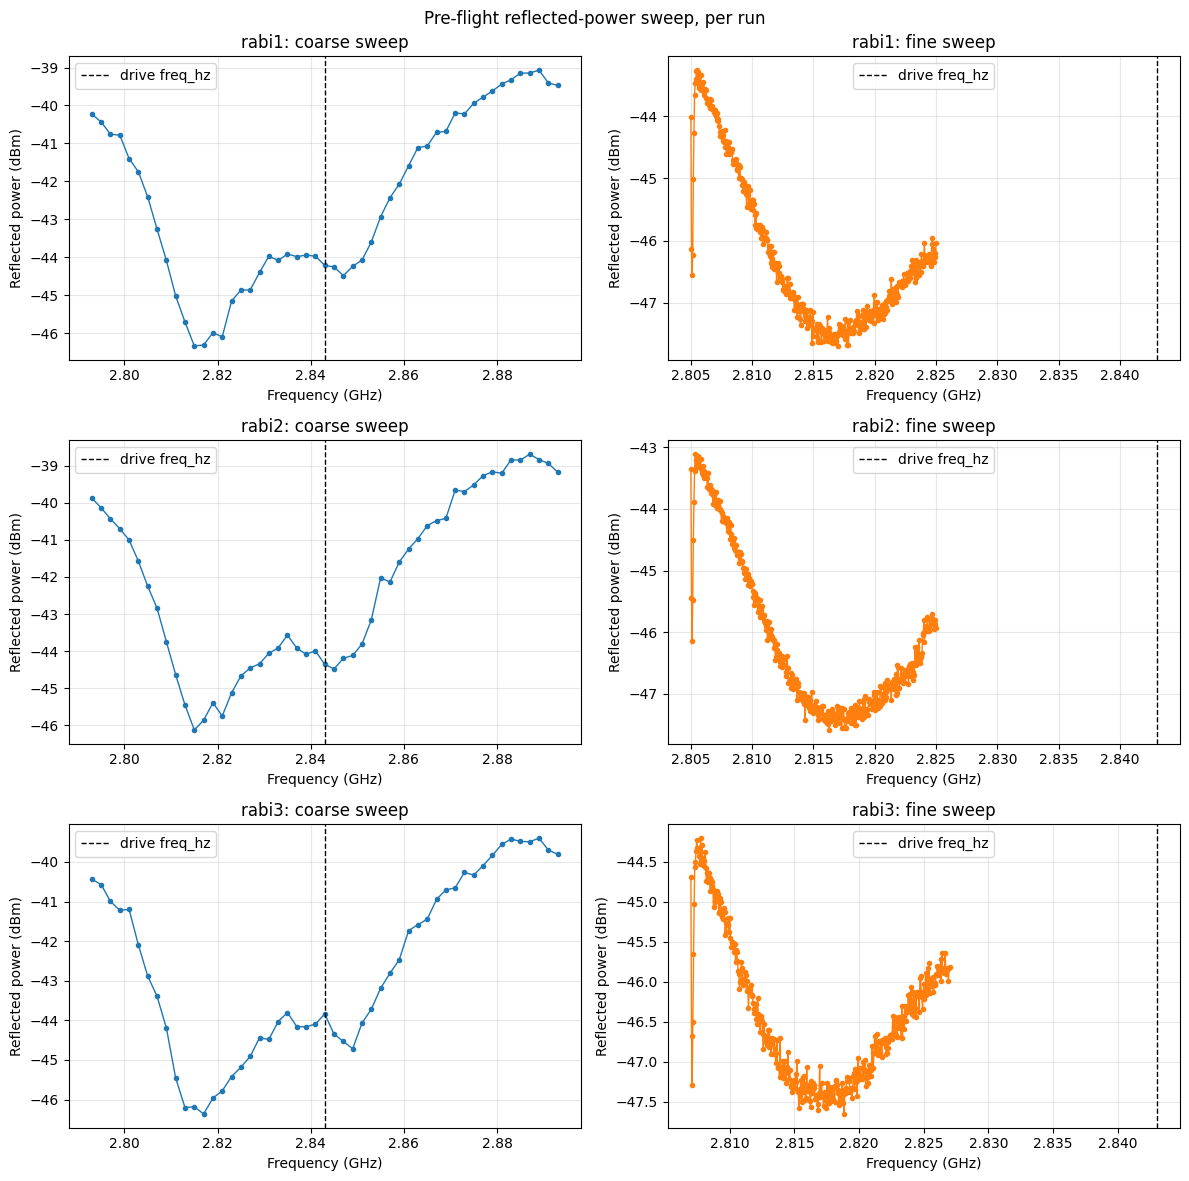

In [4]:
import os

n_runs = len(runs)
fig, axes = plt.subplots(n_runs, 2, figsize=(12, 4 * n_runs), squeeze=False)

for row, (file_name, d) in enumerate(runs.items()):
    coarse_path = f"{d['run_path']}/{file_name}_resonance_coarse.csv"
    fine_path = f"{d['run_path']}/{file_name}_resonance_fine.csv"
    if not (os.path.exists(coarse_path) and os.path.exists(fine_path)):
        axes[row, 0].set_title(f"{file_name}: no resonance CSVs found")
        axes[row, 1].set_title(f"{file_name}: no resonance CSVs found")
        print(f"{file_name}: no resonance_coarse/fine.csv found "
              "(reflected_power_scan=false, or an older run predating this feature).")
        continue

    coarse = np.genfromtxt(coarse_path, delimiter=",", names=True)
    fine = np.genfromtxt(fine_path, delimiter=",", names=True)
    freq_ghz = d["metadata"]["freq_hz"] / 1e9

    axes[row, 0].plot(coarse["frequency_hz"] / 1e9, coarse["power_dbm"], "o-", ms=3, lw=1)
    axes[row, 0].axvline(freq_ghz, color="k", ls="--", lw=1, label="drive freq_hz")
    axes[row, 0].set_xlabel("Frequency (GHz)")
    axes[row, 0].set_ylabel("Reflected power (dBm)")
    axes[row, 0].set_title(f"{file_name}: coarse sweep")
    axes[row, 0].legend()
    axes[row, 0].grid(alpha=0.3)

    axes[row, 1].plot(fine["frequency_hz"] / 1e9, fine["power_dbm"], "o-", ms=3, lw=1, color="tab:orange")
    axes[row, 1].axvline(freq_ghz, color="k", ls="--", lw=1, label="drive freq_hz")
    axes[row, 1].set_xlabel("Frequency (GHz)")
    axes[row, 1].set_ylabel("Reflected power (dBm)")
    axes[row, 1].set_title(f"{file_name}: fine sweep")
    axes[row, 1].legend()
    axes[row, 1].grid(alpha=0.3)

fig.suptitle("Pre-flight reflected-power sweep, per run")
plt.tight_layout()
plt.show()
